In [1]:
# Generated by Copilot on "2026-03-12"!!
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


## Sistema N-cuerpos

### Marzo 12

In [2]:
m1 = 1.0
m2 = 1.0
m3 = 0.1

sistema = [
    dict(m = m1, r = np.array([0, 0, 0]), v = np.array([0, 0, 0])),
    dict(m = m2, r = np.array([-1, 0, 0]), v = np.array([0, 1, 0.5])), # Orbita
    dict(m = m3, r = np.array([1, 0, 0]), v = np.array([0, -0.1, 0])) # Se escapa
]

ts = np.linspace(0, 50, 500)

In [3]:
# Generated by Copilot on "2026-03-12"!!
# Integración N-cuerpos usando `ncuerpos_solucion`

rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

# rs tiene forma (N, Nt, 3)
rs.shape, vs.shape, rps.shape, vps.shape

((3, 500, 3), (3, 500, 3), (3, 500, 3), (3, 500, 3))

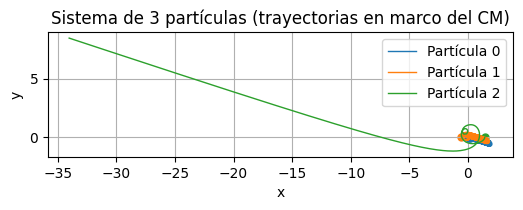

{'M': numpy.float64,
 'RCM': (500, 3),
 'PCM': (3,),
 'L': (3,),
 'K': (500,),
 'U': (500,),
 'E': numpy.float64}

In [4]:
# Generated by Copilot on "2026-03-12"!!
# Gráfica 2D (plano xy) de las trayectorias relativas al centro de masa
n_particulas = rs.shape[0]

plt.figure(figsize=(6, 6))
for i in range(n_particulas):
    plt.plot(rps[i, :, 0], rps[i, :, 1], lw=1, label=f"Partícula {i}")
    # Marcador de posición inicial (para que no "se pierdan" si las curvas se sobreponen)
    plt.scatter(rps[i, 0, 0], rps[i, 0, 1], s=25)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sistema de 3 partículas (trayectorias en marco del CM)")
plt.legend()
plt.grid(True)
plt.show()

# (Opcional) chequeo rápido de constantes de movimiento (formas)
{k: (np.array(v).shape if hasattr(v, '__len__') else type(v)) for k, v in constantes.items()}

In [7]:
# Generated by Copilot on "2026-03-12"!!
# Gráfica 3D de las trayectorias (marco del CM)
import plotly.graph_objects as go

n_particulas = rs.shape[0]
fig = go.Figure()
for i in range(n_particulas):
    fig.add_trace(
        go.Scatter3d(
            x=rps[i, :, 0],
            y=rps[i, :, 1],
            z=rps[i, :, 2],
            mode="lines",
            name=f"Partícula {i}",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=[rps[i, 0, 0]],
            y=[rps[i, 0, 1]],
            z=[rps[i, 0, 2]],
            mode="markers",
            marker=dict(size=4),
            showlegend=False,
        )
    )

fig.update_layout(scene=dict(aspectmode="data"))
fig.show()

In [8]:
# Generated by Copilot on "2026-03-12"!!
# Gráfica 3D de las trayectorias (marco del CM)
import plotly.graph_objects as go

n_particulas = rs.shape[0]
fig = go.Figure()
for i in range(n_particulas):
    fig.add_trace(
        go.Scatter3d(
            x=rs[i, :, 0],
            y=rs[i, :, 1],
            z=rs[i, :, 2],
            mode="lines",
            name=f"Partícula {i}",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=[rs[i, 0, 0]],
            y=[rs[i, 0, 1]],
            z=[rs[i, 0, 2]],
            mode="markers",
            marker=dict(size=4),
            showlegend=False,
        )
    )

fig.update_layout(scene=dict(aspectmode="data"))
fig.show()

In [9]:
K = 0

for i in range(3):
    K += 0.5 * sistema[i]['m'] * (vs[i,0,0]**2 + vs[i,0,1]**2 + vs[i,0,2]**2)**0.5
K

np.float64(0.5640169943749475)

In [10]:
U = 0
G = 1.0


for i in range(3):
    for j in range(i+1, 3):
        rij = ((rs[i,0,0] - rs[j,0,0])**2 + (rs[i,0,1] - rs[j,0,1])**2 + (rs[i,0,2] - rs[j,0,2])**2)**0.5
        U -= G * sistema[i]['m'] * sistema[j]['m'] / rij

U

np.float64(-1.1500000000000001)

In [11]:
E = K + U
E

np.float64(-0.5859830056250527)

In [24]:
#Inercia and G

I = 0
G = 0

for i in range(3):
    I += sistema[i]['m'] * np.linalg.norm(rps[i,:,:], axis=1)**2
    G += sistema[i]['m'] * rps[i,:,:] * vps[i,:,:]


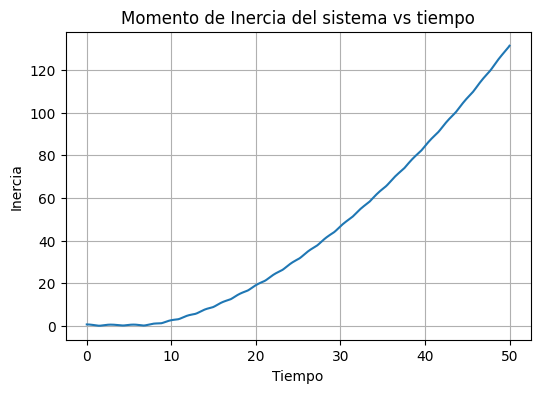

In [25]:
#graph I vs t
plt.figure(figsize=(6, 4))
plt.plot(ts, I)
plt.xlabel("Tiempo")
plt.ylabel("Inercia")
plt.title("Momento de Inercia del sistema vs tiempo")
plt.grid(True)
plt.show()

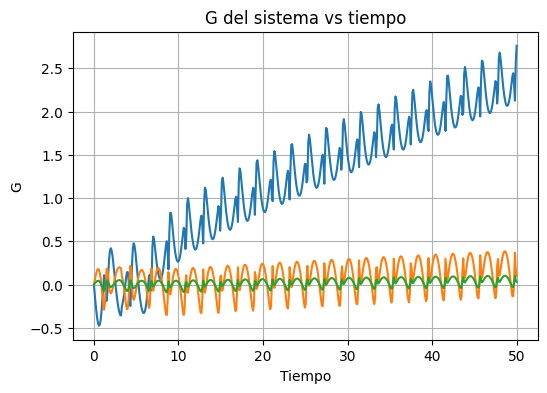

In [26]:
# graph G vs t
plt.figure(figsize=(6, 4))
plt.plot(ts, G)
plt.xlabel("Tiempo")
plt.ylabel("G")
plt.title("G del sistema vs tiempo")
plt.grid(True)
plt.show()